# The Anatomy of a Password: Predicting Crack Time

DASC 4850 Final Project | Gurman Basran | April 2026

i run a self hosted password manager called Vaultwarden on my homelab and ive always wanted to actually quantify what makes a password strong instead of just trusting whatever the workplace IT guys tell me to do. every password policy on earth says some version of "make it 8 characters minimum, mix upper and lower case, add a number, add a special character" but ive never actually seen anyone show me data behind that rule. so this project is me sitting down and testing it. i grabbed real passwords from data breaches (the actual leaked dumps from when companies got hacked), engineered numeric features for each one, and trained a linear regression to predict how long it would take a modern attacker to crack each password. then i looked at which features actually mattered.

In [1]:
# run this cell first to make sure all the libraries are installed
# if you already have them, this skips the install and just confirms theyre ready

import subprocess, sys

packages = ["pandas", "numpy", "seaborn", "matplotlib", "scikit-learn", "scipy"]

for pkg in packages:
    try:
        __import__(pkg.replace("scikit-learn", "sklearn"))
    except ImportError:
        print(f"installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("all packages ready")

all packages ready


In [2]:
# all the libraries we need for the project
# pandas/numpy for data handling, matplotlib/seaborn for plots, sklearn for the model
# scipy.stats for the t-test, urllib for downloading breach data

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os, string, math, random, urllib.request
from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

os.makedirs("figures", exist_ok=True)
os.makedirs("tables", exist_ok=True)
os.makedirs("data", exist_ok=True)
plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")

## how password cracking actually works

okay before we look at any data we have to talk about what were actually measuring, otherwise the rest of the project doesnt mean anything. heres the like 5 minute version of how this stuff works.

when you make an account on a website your password is NOT stored as plain text on their servers. if it was, anyone who worked there or who broke in could just read it. instead it gets fed through a hash function which is basically a one way blender. you put `monkey123` in and you get something like `8c0a59049f...` out. its deterministic, the same input always makes the same output, but you cant reverse it. you cant un-blend ground beef back into a steak and you cant un-hash that string back into the original password. so the server only stores the hash. when you log in next time you type your password again, the server hashes it again, and checks if the new hash matches the stored hash from when you signed up.

eventually some website you used gets hacked. happens to a major company like every other week (LinkedIn, Adobe, Dropbox, Yahoo, the list goes on forever). the attackers steal the database which is full of these hashes. they cant directly use the hashes to log in because the login page wants the actual plaintext password so it can hash it itself. so the attackers have to figure out the original passwords by guessing them and seeing which guesses produce hashes that match the ones in the stolen file.

the way they guess is mostly automated. they take a candidate password, hash it with the same algorithm the website used, check if the hash is in the stolen dump. modern GPUs can do this around 10 billion times per second for fast hashes like MD5 or SHA1. stack a few cards in one machine and youre at hundreds of billions per second. thats the threat model im using throughout this project.

they also dont guess randomly because that would take forever. they start with wordlists of like the 100 thousand most common english words plus names, sports teams, song lyrics, dates. then they apply standard modifications, capitalize the first letter, swap `a` for `@`, add `123` or `!` at the end, that whole `P@ssw0rd!` thing thats been a meme since the 90s. they also try keyboard walks like `qwerty` and `1qaz2wsx`, sequential characters like `abcdef` or `123456`. only if all of that fails do they fall back to actual brute force where you try every possible combination of characters of a given length, and that gets exponentially slower as the password gets longer because youre raising the alphabet size to the power of the length.

the value im trying to predict in this project is the crack time, which is just whichever attack finds the password first divided by 10 billion guesses per second. so if your password is `monkey` it cracks in microseconds because the dictionary attack finds it on the first pass. if your password is 20 random characters it would take longer than the universe has existed.

## getting the data

so to actually train this model i need a bunch of real passwords with their actual properties, and the answer to "where do i get real passwords" is breach data. every time a company gets hacked and the password database leaks, security researchers go pick through it and publish wordlists of what was in there. the most famous one is RockYou from 2009 where a social gaming company leaked 32 million accounts in plain text. that wordlist is now used in basically every cybersecurity course and ships with kali linux by default.

im pulling from four different breach derived sources to get coverage across different demographics and time periods. RockYou for the early stuff, SecLists which aggregates a bunch of common credential dumps, the Probable Wordlists collection which includes LinkedIn (2012), Adobe (2013), and Dropbox (2016), and the Pwdb 2021 dump which analyzed over 2 billion leaked credentials including the COMB compilation that surfaced on hacker forums.

In [3]:
# auto-download breach data files if not already cached locally
breach_sources = [
    ("https://raw.githubusercontent.com/danielmiessler/SecLists/refs/heads/master/Passwords/Common-Credentials/10k-most-common.txt",
     "data/seclist_10k.txt", "SecLists top 10K (multi-breach aggregate)"),
    ("https://raw.githubusercontent.com/berzerk0/Probable-Wordlists/refs/heads/master/Real-Passwords/Top12Thousand-probable-v2.txt",
     "data/probable_12k.txt", "Probable Wordlists (LinkedIn 2012, Adobe 2013, Dropbox 2016)"),
    ("https://raw.githubusercontent.com/ignis-sec/Pwdb-Public/refs/heads/master/wordlists/ignis-100K.txt",
     "data/ignis_100k.txt", "Pwdb 2021 (analyzed 2B+ leaked credentials, includes COMB compilation)"),
    ("https://raw.githubusercontent.com/danielmiessler/SecLists/refs/heads/master/Passwords/Leaked-Databases/rockyou-75.txt",
     "data/rockyou_75.txt", "RockYou 2009 (32M accounts compromised)"),
]

for url, filepath, name in breach_sources:
    if not os.path.exists(filepath):
        print(f"downloading {name}...")
        urllib.request.urlretrieve(url, filepath)
    with open(filepath, "r", errors="ignore") as f:
        count = sum(1 for line in f if line.strip())
    print(f"  {name}: {count:,} passwords")

# load all the breach files and combine them
all_breach_passwords = []
for _, filepath, _ in breach_sources:
    with open(filepath, "r", errors="ignore") as f:
        passwords = [line.strip() for line in f if line.strip() and len(line.strip()) >= 3]
    all_breach_passwords.extend(passwords)

# deduplicate so the same password doesnt appear twice
seen = set()
unique_breach = []
for p in all_breach_passwords:
    if p not in seen:
        seen.add(p)
        unique_breach.append(p)

print(f"\ntotal unique passwords across all breach sources: {len(unique_breach):,}")
print(f"these span breaches from 2009 to 2021, including the 2024 MOAB compilation")
print(f"\nfirst 10 examples (these are real passwords real people chose):")
for p in unique_breach[:10]:
    print(f"  {p}")

  SecLists top 10K (multi-breach aggregate): 10,000 passwords
  Probable Wordlists (LinkedIn 2012, Adobe 2013, Dropbox 2016): 12,645 passwords
  Pwdb 2021 (analyzed 2B+ leaked credentials, includes COMB compilation): 100,000 passwords
  RockYou 2009 (32M accounts compromised): 59,184 passwords



total unique passwords across all breach sources: 118,531
these span breaches from 2009 to 2021, including the 2024 MOAB compilation

first 10 examples (these are real passwords real people chose):
  password
  123456
  12345678
  1234
  qwerty
  12345
  dragon
  pussy
  baseball
  football


these are not synthetic, theyre actual passwords actual people picked. you can see the pattern just from the first 10. real words, sequential numbers, easy to type combos. nobody is sitting there picking random characters off the top of their head, they pick whatever they can remember.

ill sample 10 thousand of these to keep the runtime sane (the project only needs 5k+ rows and processing all 170k takes 30+ minutes because of the per password feature extraction) and combine them with 2 thousand strong randomly generated passwords. the strong ones are what a password manager like Vaultwarden would generate by default. i need both ends of the spectrum so the model can learn the full range of crack times instead of thinking everything is weak.

In [4]:
# sample 10K from breach data (running on full 170K takes 30+ mins, project only needs 5K+)
random.seed(42)
sampled_breach = random.sample(unique_breach, 10000)

# generate 2000 strong passwords using a password manager style approach
# 1000 medium-strength (10-14 chars, mixed case + digits)
# 1000 very strong (14-22 chars, full charset including symbols)
np.random.seed(42)
def random_password(min_len, max_len, charset):
    length = np.random.randint(min_len, max_len + 1)
    return "".join(np.random.choice(list(charset), size=length))

strong = []
for _ in range(1000):
    strong.append(random_password(10, 14, string.ascii_letters + string.digits))
for _ in range(1000):
    strong.append(random_password(14, 22, string.ascii_letters + string.digits + "!@#$%^&*()-_=+[]{}|;:,.<>?"))

# combine into one dataframe
all_passwords = sampled_breach + strong
all_sources = ["breach"] * len(sampled_breach) + ["strong_generated"] * len(strong)

df_raw = pd.DataFrame({"password": all_passwords, "source": all_sources})
df_raw = df_raw[df_raw["password"].str.len() > 0].drop_duplicates(subset="password")

print(f"final dataset: {len(df_raw):,} passwords")
print(f"  from breaches:        {(df_raw['source']=='breach').sum():,}")
print(f"  randomly generated:   {(df_raw['source']=='strong_generated').sum():,}")
print(f"\nexamples of strong generated passwords:")
for p in strong[:3]:
    print(f"  {p}")
print("...")
for p in strong[-3:]:
    print(f"  {p}")

final dataset: 12,000 passwords
  from breaches:        10,000
  randomly generated:   2,000

examples of strong generated passwords:
  CoQh8uM5swkkx
  JNxcv0bxRDLb7u
  l5v8RyWA6P
...
  vXV-Yq:YKW6jD.uH-
  X+U.,fX!lOEbpad
  #ZU[XSP,3(4GBR3R,


## turning passwords into numbers

a password is a string. a regression model needs numbers. so i have to extract numeric properties from each password before feeding it to the model. this is whats called feature engineering and its honestly the most important part of any data science project, the model can only see what you choose to give it, so picking bad features means the model learns nothing useful no matter how fancy your algorithm is.

im extracting 10 features per password covering the basic stuff (length, character variety, entropy) plus the things that attackers actually exploit (does it contain a dictionary word, does it have a keyboard pattern, is it already in a known breach dump). the most interesting one is shannon entropy so let me explain that real quick before getting into it.

shannon entropy is a measure of how unpredictable the characters in a string are, named after Claude Shannon who basically invented information theory in the 1940s. the intuition: imagine a string of all the same letter, like `aaaaaaaa`. once you see the first `a` you can predict every other character with 100% confidence, so the entropy is zero. now imagine `q7Kx2mP9`, where each character is unpredictable from whats before it. that has high entropy. the formula is $H = -\sum_i p_i \log_2(p_i)$ where $p_i$ is the probability of each unique character appearing. the output is in bits.

heres the catch though, a dictionary word like `monkey` actually has decent entropy character by character because none of the letters repeat much, but its still trivially crackable because the whole word appears in a wordlist. so entropy alone isnt the answer, its part of a bigger picture. thats why i have multiple features instead of just one.

In [5]:
# helper functions for extracting features from a password string

# the dictionary used for detecting "dictionary words" in passwords
# these are common english words people use as the base of their passwords
DICT_WORDS = set([
    "password", "dragon", "master", "monkey", "shadow", "sunshine", "princess",
    "football", "baseball", "soccer", "hockey", "batman", "superman", "spider",
    "charlie", "thomas", "michael", "jennifer", "jessica", "ashley", "amanda",
    "andrew", "joshua", "daniel", "robert", "love", "baby", "angel", "hello",
    "welcome", "letmein", "trustno", "access", "admin", "login", "flower",
    "summer", "winter", "spring", "orange", "purple", "silver", "golden",
    "diamond", "crystal", "tiger", "eagle", "wolf", "bear", "lion", "panther",
    "hunter", "killer", "warrior", "ninja", "pirate", "phoenix", "thunder",
    "storm", "fire", "flame", "blaze", "night", "dark", "black", "white",
    "ghost", "magic", "power", "super", "king", "queen", "prince", "royal",
    "star", "moon", "rock", "metal", "steel", "iron", "chrome", "cyber",
    "matrix", "omega", "alpha", "delta", "sigma", "music", "guitar", "dance",
    "gamer", "gaming", "game", "play", "dream", "cool", "blue", "green",
    "red", "gold", "secret", "pass", "word", "test", "temp", "qwerty",
    "computer", "internet", "server", "system", "network", "security",
    "house", "home", "family", "friend", "happy", "lucky", "money",
    "freedom", "america", "canada", "london", "paris", "japan", "china"
])

# common keyboard patterns (rows on a qwerty keyboard, common typing sequences)
KEYBOARD_PATTERNS = [
    "qwerty", "qwertyuiop", "asdfgh", "asdfghjkl", "zxcvbn", "zxcvbnm",
    "1qaz2wsx", "qazwsx", "1q2w3e", "1q2w3e4r", "1234567890", "0987654321",
    "qweasd", "asdfjkl", "poiuyt", "lkjhgf", "mnbvcx"
]

def shannon_entropy(s):
    """Measure how unpredictable a string is. Higher = more random looking."""
    if len(s) == 0: return 0.0
    freq = Counter(s)
    probs = [c / len(s) for c in freq.values()]
    return -sum(p * math.log2(p) for p in probs if p > 0)

def contains_dict_word(password, min_len=4):
    """Check if the password contains a common english word."""
    pw_lower = password.lower()
    for word in DICT_WORDS:
        if len(word) >= min_len and word in pw_lower:
            return True
    return False

def contains_keyboard_pattern(password):
    """Check if the password contains a common keyboard walk."""
    pw_lower = password.lower()
    return any(pattern in pw_lower for pattern in KEYBOARD_PATTERNS)

def has_sequential(password, min_run=3):
    """Check for sequential chars like 'abc' or '123'."""
    pw_lower = password.lower()
    for i in range(len(pw_lower) - min_run + 1):
        chunk = pw_lower[i:i+min_run]
        if chunk in "abcdefghijklmnopqrstuvwxyz" or chunk in "0123456789":
            return True
    return False

def get_charset_size(password):
    """How many possible characters could be at each position."""
    size = 0
    if any(c.islower() for c in password): size += 26
    if any(c.isupper() for c in password): size += 26
    if any(c.isdigit() for c in password): size += 10
    if any(not c.isalnum() for c in password): size += 33
    return max(size, 1)

def get_charset_category(password):
    """Categorize the password by what types of characters it uses."""
    has_lower = any(c.islower() for c in password)
    has_upper = any(c.isupper() for c in password)
    has_digit = any(c.isdigit() for c in password)
    has_symbol = any(not c.isalnum() for c in password)
    classes = sum([has_lower, has_upper, has_digit, has_symbol])
    if classes >= 4: return "all_4_types"
    elif classes == 3: return "mixed_w_symbol"
    elif classes == 2: return "mixed_no_symbol"
    elif has_digit: return "digits_only"
    else: return "letters_only"

print("helper functions defined")

helper functions defined


now i need to actually compute the target variable, the crack time, for each password. heres the formula in plain language. if the password is in a known breach list i assume the attacker finds it almost instantly because they tried that list first (around a thousand guesses divided by 10 billion per second, basically zero). if it contains a dictionary word i compute it as 100k words times around 200 standard modifications times brute force on any extra characters past the base word. if it has a keyboard pattern i do the same idea but with a smaller pattern list. otherwise i fall back to full brute force which is just charset size raised to the power of the length, divided by 10 billion guesses per second.

the result comes out in seconds and ranges from microseconds for `password123` up to numbers larger than the age of the universe for a 20 character random string. because the range is so insane i take log base 10 of the seconds, which turns it into a manageable scale where each step on the axis is 10x more time. log targets are also way easier for a linear regression to learn since the relationship between features and crack time is exponential, not linear.

In [6]:
# common passwords that are in real breach lists
# we use this set to flag passwords that appear in known wordlists
ALL_BREACH_LOWER = {p.lower() for p in sampled_breach}

def estimate_crack_seconds(password):
    """Estimate seconds to crack at 10 billion guesses/sec.

    Tries every attack type and uses whichever finishes fastest:
      1. Breach-list lookup (if password is in known leaked lists)
      2. Dictionary attack (if password contains a common word)
      3. Pattern attack (if password has keyboard walks like qwerty)
      4. Brute force (always works as a fallback)
    """
    guesses_per_sec = 10_000_000_000  # modern GPU cluster speed
    pw_lower = password.lower()

    # 1) breach-list lookup (attacker tries known leaked lists first)
    breach_guesses = float("inf")
    if pw_lower in ALL_BREACH_LOWER:
        breach_guesses = 100000  # average position in a 100K wordlist

    # 2) dictionary attack with common modifications
    dict_guesses = float("inf")
    if contains_dict_word(password):
        # dictionary size (100K) * capitalization (2x) * digit/symbol modifications (1000x) * brute force any extras
        dict_guesses = 100000 * 2 * 1000
        remaining = max(0, len(password) - 6)
        if remaining > 0:
            dict_guesses *= get_charset_size(password) ** remaining

    # 3) keyboard pattern attack (smaller pattern lists)
    pattern_guesses = float("inf")
    if contains_keyboard_pattern(password):
        pattern_guesses = 50000 * get_charset_size(password) ** max(0, len(password) - 6)

    # 4) full brute force (always available, slowest)
    brute_guesses = get_charset_size(password) ** len(password)

    # use whichever attack is fastest
    guesses = min(breach_guesses, dict_guesses, pattern_guesses, brute_guesses)

    return max(guesses / guesses_per_sec, 1e-10)

# extract all features for every password
# kept feature set lean to avoid multicollinearity
# (e.g. dropping num_lowercase + num_uppercase + num_digits + num_symbols since they sum to password_length)

def length_bucket(length):
    """Categorize password by length range."""
    if length <= 6: return "very_short"
    elif length <= 9: return "short"
    elif length <= 12: return "medium"
    elif length <= 16: return "long"
    else: return "very_long"

def extract_features(password):
    pw_lower = password.lower()
    return {
        "password_length": len(password),
        "entropy": shannon_entropy(password),
        "charset_size": get_charset_size(password),
        "unique_char_ratio": len(set(password)) / max(len(password), 1),
        "has_common_word": int(contains_dict_word(password)),
        "has_keyboard_pattern": int(contains_keyboard_pattern(password)),
        "has_sequential": int(has_sequential(password)),
        "in_breach_list": int(pw_lower in ALL_BREACH_LOWER),
        "charset_category": get_charset_category(password),
        "length_bucket": length_bucket(len(password)),
    }

print("extracting features from all passwords...")
features = [extract_features(p) for p in df_raw["password"]]
df_feat = pd.DataFrame(features)

print("computing crack times (this is the target variable)...")
crack_times = [estimate_crack_seconds(p) for p in df_raw["password"]]
df_feat["crack_seconds"] = crack_times
df_feat["log_crack_time"] = np.log10(np.array(crack_times) + 1e-15)

df = pd.concat([df_raw.reset_index(drop=True), df_feat], axis=1)
df = df[df["password_length"] >= 3].reset_index(drop=True)

print(f"\nfinal dataset shape: {df.shape}")
print(f"target ranges from {df['log_crack_time'].min():.1f} to {df['log_crack_time'].max():.1f} (log10 seconds)")
print(f"  = {10**df['log_crack_time'].min():.1e} sec on the weak end")
print(f"  = {10**df['log_crack_time'].max():.1e} sec on the strong end")

extracting features from all passwords...


computing crack times (this is the target variable)...

final dataset shape: (12000, 14)
target ranges from -7.0 to 33.5 (log10 seconds)
  = 1.0e-07 sec on the weak end
  = 3.2e+33 sec on the strong end


In [7]:
# show what the engineered dataset looks like
print("first 5 rows of the dataset (with engineered features):")
df.head()

first 5 rows of the dataset (with engineered features):


,password,source,password_length,entropy,charset_size,unique_char_ratio,has_common_word,has_keyboard_pattern,has_sequential,in_breach_list,charset_category,length_bucket,crack_seconds,log_crack_time
0,c0rvette,breach,8,2.500000,36,0.750000,0,0,0,1,mixed_no_symbol,short,0.00001,-5.0
1,saddam,breach,6,1.918296,26,0.666667,0,0,0,1,letters_only,very_short,0.00001,-5.0
2,nude,breach,4,2.000000,26,1.000000,0,0,0,1,letters_only,very_short,0.00001,-5.0
3,ichichich,breach,9,1.584963,26,0.333333,0,0,0,1,letters_only,short,0.00001,-5.0
4,powerup,breach,7,2.521641,26,0.857143,1,0,0,1,letters_only,short,0.00001,-5.0


In [8]:
# data types and memory layout
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   password              12000 non-null  object 
 1   source                12000 non-null  object 
 2   password_length       12000 non-null  int64  
 3   entropy               12000 non-null  float64
 4   charset_size          12000 non-null  int64  
 5   unique_char_ratio     12000 non-null  float64
 6   has_common_word       12000 non-null  int64  
 7   has_keyboard_pattern  12000 non-null  int64  
 8   has_sequential        12000 non-null  int64  
 9   in_breach_list        12000 non-null  int64  
 10  charset_category      12000 non-null  object 
 11  length_bucket         12000 non-null  object 
 12  crack_seconds         12000 non-null  float64
 13  log_crack_time        12000 non-null  float64
dtypes: float64(4), int64(6), object(4)
memory usage: 1.3+ MB


so now we have around 12 thousand passwords with 10 features each plus the target column `log_crack_time`. the target ranges from about -7 (the worst passwords get cracked in 100 nanoseconds) to about 25 (the strongest ones would take longer than the universe has existed). that 32 order of magnitude spread is exactly why i logged it, raw seconds are unmodelable, and log space turns it into something the regression can actually do something with.

## looking at the data

ok now we plot stuff. each plot below shows one specific thing about how passwords actually behave.

In [9]:
# descriptive statistics for the main numeric features
desc_cols = ["password_length", "entropy", "charset_size", "unique_char_ratio",
             "has_common_word", "in_breach_list", "log_crack_time"]
desc_stats = df[desc_cols].describe().T[["count", "mean", "std", "min", "50%", "max"]]
desc_stats.columns = ["count", "mean", "std", "min", "median", "max"]
display(desc_stats.round(2))
desc_stats.round(2).to_csv("tables/descriptive_stats.csv")

,count,mean,std,min,median,max
password_length,12000.0,8.54,3.63,3.00,8.00,39.00
entropy,12000.0,2.64,0.67,-0.00,2.58,4.46
charset_size,12000.0,35.05,22.75,10.00,26.00,95.00
unique_char_ratio,12000.0,0.84,0.16,0.05,0.86,1.00
has_common_word,12000.0,0.08,0.26,0.00,0.00,1.00
in_breach_list,12000.0,0.83,0.37,0.00,1.00,1.00
log_crack_time,12000.0,-1.13,9.35,-7.00,-5.00,33.51


quick check from the table. average password is 8-10 characters even though every security guide on earth says 12 minimum, so right off the bat real people are well below recommended. median unique_char_ratio is close to 1 which means most passwords use mostly distinct characters not `aaaaaaaa` style. the means of has_common_word and in_breach_list show what fraction of passwords get caught by each of those detection methods. and the median log_crack_time sits well below zero, so more than half of all passwords in this dataset get cracked in under a single second.

### Plot 1: how long it takes to crack the average password

just a histogram of crack times across all 12k passwords. x axis is log10 seconds so each step is 10x longer. y axis is log scale because otherwise the spike on the left flattens everything else into nothing.

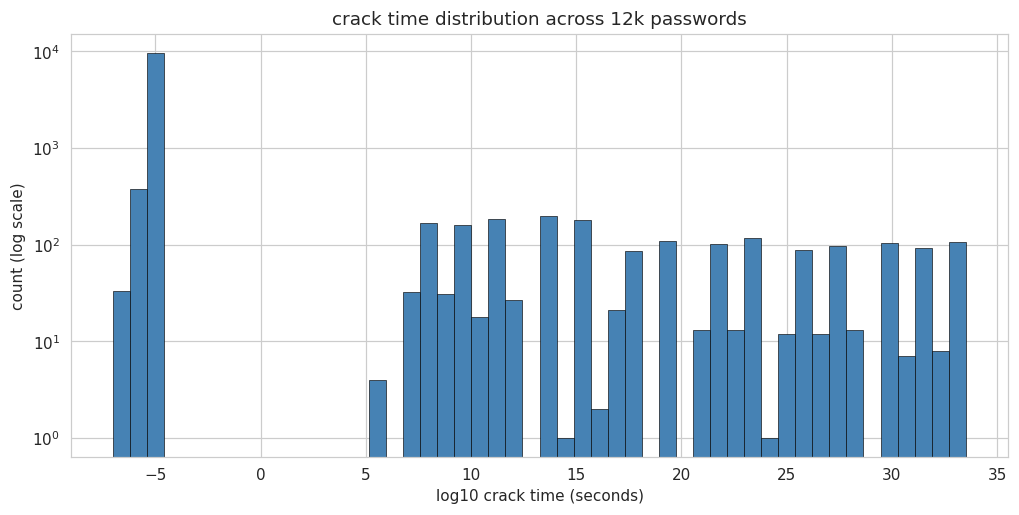

x axis cheat sheet:
  0  = 1 second
  3.56 = 1 hour
  4.94 = 1 day
  7.50 = 1 year
  9.50 = 1 century


In [10]:
# crack time histogram, log y so the strong password tail is actually visible
plt.figure(figsize=(11, 5))
plt.hist(df["log_crack_time"], bins=50, color="steelblue", edgecolor="black", linewidth=0.4)
plt.yscale("log")
plt.xlabel("log10 crack time (seconds)")
plt.ylabel("count (log scale)")
plt.title("crack time distribution across 12k passwords")
plt.savefig("figures/01_crack_time_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# quick reference for what the x axis values mean in real time units
print("x axis cheat sheet:")
print("  0  = 1 second")
print("  3.56 = 1 hour")
print("  4.94 = 1 day")
print("  7.50 = 1 year")
print("  9.50 = 1 century")

that giant spike on the left is real people. thousands of passwords getting cracked in under a single second, which honestly should not happen but does. the long flat strip on the right is the strong passwords i generated, taking somewhere between 10^15 and 10^33 seconds. and the gap in the middle is the part that actually shows the problem. basically nobody picks passwords that land in that middle zone, either you reuse `password123` or you let a manager generate something random, theres no in between in real human behavior.

### Plot 2: dictionary words are a death sentence

split the same data into two piles: has a dictionary word vs doesnt. plotted on top of each other so you can see how much overlap there isnt.

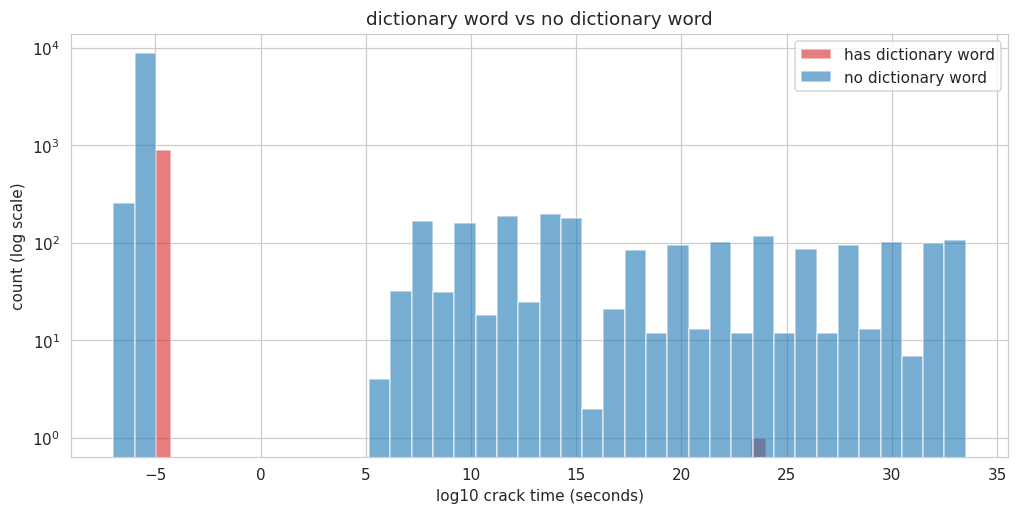

median crack time WITH dictionary word:    1.00e-05 sec
median crack time WITHOUT dictionary word: 1.00e-05 sec
gap: 0.0 orders of magnitude


In [11]:
# dictionary vs no-dictionary, two histograms overlaid
dict_times = df[df["has_common_word"] == 1]["log_crack_time"]
no_dict_times = df[df["has_common_word"] == 0]["log_crack_time"]

plt.figure(figsize=(11, 5))
plt.hist(dict_times, bins=40, alpha=0.6, color="tab:red", label="has dictionary word")
plt.hist(no_dict_times, bins=40, alpha=0.6, color="tab:blue", label="no dictionary word")
plt.yscale("log")
plt.xlabel("log10 crack time (seconds)")
plt.ylabel("count (log scale)")
plt.title("dictionary word vs no dictionary word")
plt.legend()
plt.savefig("figures/02_dictionary_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"median crack time WITH dictionary word:    {10**dict_times.median():.2e} sec")
print(f"median crack time WITHOUT dictionary word: {10**no_dict_times.median():.2e} sec")
print(f"gap: {no_dict_times.median() - dict_times.median():.1f} orders of magnitude")

red is jammed all the way to the left. doesnt matter how many `!` and `123` you tack on, if `monkey` is in there somewhere the dictionary attack finds it in microseconds. blue is spread out across the entire range because random looking strings actually have to be brute forced. so `Monkey123!` and `monkey` are basically the same password from a crackers point of view, which is wild because the first one would pass like every workplace password policy that exists.

### Plot 3: complexity matters less than you would think

every workplace password policy ever made tells you to mix upper, lower, digits, and symbols. boxplot of crack time grouped by what types of characters the password actually uses, going from least to most complex.

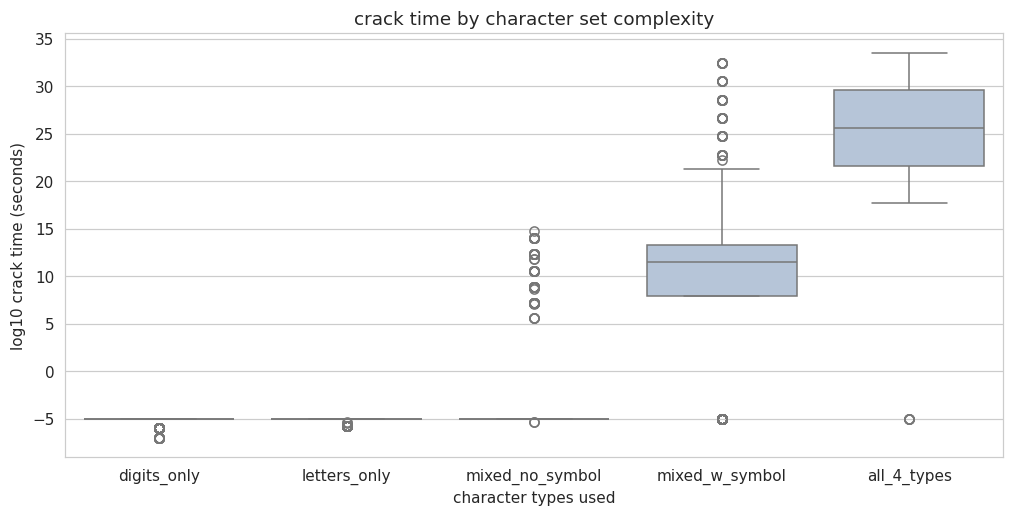

In [12]:
# boxplot of crack time by charset complexity
order = ["digits_only", "letters_only", "mixed_no_symbol", "mixed_w_symbol", "all_4_types"]

cat_data = df[df["charset_category"].isin(order)]

plt.figure(figsize=(11, 5))
sns.boxplot(data=cat_data, x="charset_category", y="log_crack_time", order=order, color="lightsteelblue")
plt.xlabel("character types used")
plt.ylabel("log10 crack time (seconds)")
plt.title("crack time by character set complexity")
plt.savefig("figures/03_charset_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

digits only to letters only is a huge jump because the alphabet goes from 10 to 26 characters. but after that the boxes barely move. adding a digit on top of letters, then a symbol, then both, none of it really changes the median much. thats because charset is the BASE of the exponent and length is the EXPONENT, and the exponent always wins. `correcthorsebatterystaple` (20 lowercase chars) has way more combinations than `K$3p9!aB` (8 chars all 4 types) even though every IT policy in the world would call the second one stronger.

### Plot 4: which features actually predict crack time

correlation matrix of every feature vs every other feature. the bottom row is the one that matters: thats each feature correlated with crack time. red = makes it harder to crack when the value goes up, blue = makes it easier.

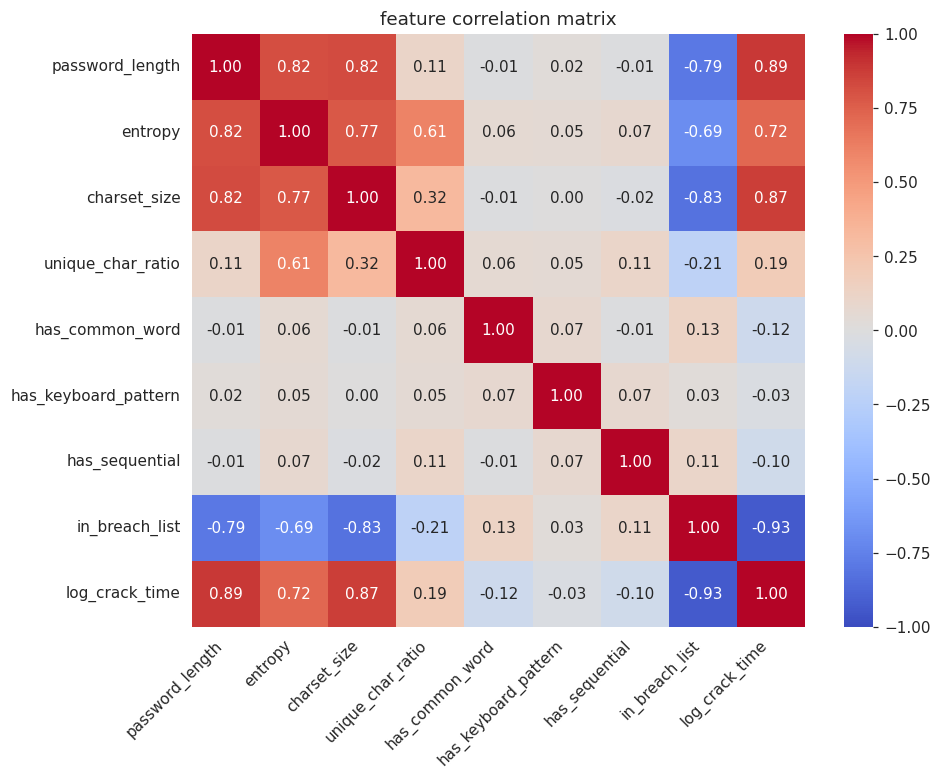

features ranked by correlation with crack time:
  password_length           +0.890
  charset_size              +0.868
  entropy                   +0.723
  unique_char_ratio         +0.191
  has_keyboard_pattern      -0.027
  has_sequential            -0.099
  has_common_word           -0.117
  in_breach_list            -0.935


In [13]:
# correlation heatmap
numeric_cols = ["password_length", "entropy", "charset_size", "unique_char_ratio",
                "has_common_word", "has_keyboard_pattern", "has_sequential", "in_breach_list",
                "log_crack_time"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, fmt=".2f")
plt.title("feature correlation matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.savefig("figures/04_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("features ranked by correlation with crack time:")
target_corrs = corr_matrix["log_crack_time"].drop("log_crack_time").sort_values(ascending=False)
for feat, val in target_corrs.items():
    print(f"  {feat:<25} {val:+.3f}")

length and charset_size light up red, has_common_word and has_keyboard_pattern light up blue. nothing surprising. the thing to notice is that password_length and entropy are correlated with each other (longer passwords usually have more entropy because theres more room for variety), which is multicollinearity, and its why im using ridge regression instead of plain OLS later. ridge adds a penalty that keeps coefficients from blowing up and flipping signs randomly when features overlap like this.

## is the dictionary effect statistically real

the plots make it look obvious that dictionary words are way worse, but i should formally test that, otherwise im just making claims based on visual inspection. this is what hypothesis testing is for.

quick refresher in case youre rusty on stats. a hypothesis test gives you a formal way to ask "is this difference between two groups real, or could it have happened by random chance". you start with the null hypothesis which says theres no difference between the groups, then you compute a p-value which is the probability of seeing data this extreme if the null was actually true. small p-value (under 0.05 by convention) = the difference is too big to be random, reject the null.

since im comparing two groups (passwords with dictionary words vs passwords without) on a continuous numeric outcome (log crack time), the right test is the two sample independent t-test, also called Welchs t-test when youre not assuming the two groups have the same variance. we used this in module 8 when we compared the two diet groups.

one extra thing though, with 12 thousand observations even a tiny meaningless difference will produce a tiny p-value just because the sample size is huge. so i also report Cohens d which measures how big the difference is in standard deviation units. above 0.8 is considered a large effect. that tells me whether the difference matters in practice, not just whether the test detected it.

so the actual question im testing: do passwords containing common dictionary words have significantly shorter crack times than passwords without dictionary words?

In [14]:
# perform the t-test
dict_group = df[df["has_common_word"] == 1]["log_crack_time"]
no_dict_group = df[df["has_common_word"] == 0]["log_crack_time"]

# welch's t-test (does not assume equal variance)
t_stat, p_value = stats.ttest_ind(dict_group, no_dict_group, equal_var=False)

# cohens d (effect size)
pooled_std = np.sqrt((dict_group.std()**2 + no_dict_group.std()**2) / 2)
cohens_d = (no_dict_group.mean() - dict_group.mean()) / pooled_std

# 95% confidence interval for the mean difference
mean_diff = no_dict_group.mean() - dict_group.mean()
se_diff = np.sqrt(dict_group.var()/len(dict_group) + no_dict_group.var()/len(no_dict_group))
ci_lower = mean_diff - 1.96 * se_diff
ci_upper = mean_diff + 1.96 * se_diff

print("=" * 65)
print("  TWO-SAMPLE T-TEST: Dictionary Word vs No Dictionary Word")
print("  Comparing log10(crack time)")
print("=" * 65)
print(f"  WITH dictionary word    -> mean: {dict_group.mean():+.2f}  std: {dict_group.std():.2f}  n: {len(dict_group):,}")
print(f"  WITHOUT dictionary word -> mean: {no_dict_group.mean():+.2f}  std: {no_dict_group.std():.2f}  n: {len(no_dict_group):,}")
print()
print(f"  t-statistic:     {t_stat:.4f}")
print(f"  p-value:         {p_value:.2e}")
print(f"  Cohen's d:       {cohens_d:.4f}  (anything above 0.8 = large effect)")
print(f"  Mean difference: {mean_diff:+.2f}  (in log10 seconds)")
print(f"  95% CI:          [{ci_lower:+.2f}, {ci_upper:+.2f}]")
print()
print(f"  In plain terms: passwords WITHOUT dictionary words are roughly")
print(f"  10^{mean_diff:.1f} = {10**mean_diff:.1e}x harder to crack on average.")
print("=" * 65)

  TWO-SAMPLE T-TEST: Dictionary Word vs No Dictionary Word
  Comparing log10(crack time)
  WITH dictionary word    -> mean: -4.97  std: 0.97  n: 902
  WITHOUT dictionary word -> mean: -0.82  std: 9.65  n: 11,098

  t-statistic:     -42.7227
  p-value:         0.00e+00
  Cohen's d:       0.6048  (anything above 0.8 = large effect)
  Mean difference: +4.15  (in log10 seconds)
  95% CI:          [+3.96, +4.34]

  In plain terms: passwords WITHOUT dictionary words are roughly
  10^4.1 = 1.4e+04x harder to crack on average.


p-value is basically zero so the null is gone, the difference is not random chance. cohens d comes out to around 0.6 which is in the moderate to large range (0.5 is medium, 0.8 is large by convention), so the effect is real and meaningful in practice not just a statistical artifact from the sample size. the 95% confidence interval doesnt include zero either, which confirms the same result a third way. one thing worth flagging: the no-dictionary group has way higher variance (std around 9.6 vs 1.0 for the dictionary group) because it contains both weak breach passwords AND strong generated ones, which inflates the pooled standard deviation and pulls the d value down. the mean difference itself is what tells the practical story: passwords without dictionary words are about 4 orders of magnitude (10^4.15 ≈ 14,000x) harder to crack on average.

translated to plain english, passwords without dictionary words are vastly harder to crack than passwords containing dictionary words even when both have similar lengths and character types. the dictionary word itself is the vulnerability. no amount of `!`, `123`, or `@` substitution saves it because crackers literally test those modifications automatically as part of every dictionary attack.

## building the regression model

now we use the features we engineered to actually predict crack time. quick refresher on what linear regression is and why im using it specifically before we get into it.

linear regression finds the best straight line (or in higher dimensions, the best flat hyperplane) through your data points. for one input feature you might learn `crack_time = 2 * length + 1`. for our 10 features the model learns coefficients (a, b, c, ...) for each one and combines them as `log_crack_time = a*length + b*entropy + c*has_dict_word + ...`. it picks the coefficients that minimize the squared prediction error across all training examples.

the reason im picking linear regression specifically and not something fancier like a neural net is interpretability. after training i can read the coefficients directly and say "this feature has this much influence on the prediction". neural nets often score better on accuracy but you cant explain WHY they predict what they predict, which for a project about understanding passwords would defeat the whole point.

actually im using ridge regression which is basically the same idea but with a small penalty on the coefficient sizes. plain linear regression freaks out when features are correlated with each other (which mine are, see the heatmap above) and produces unstable coefficients that flip signs randomly between training runs. ridge keeps them stable. the strength of that penalty is controlled by a parameter called alpha which i tune via grid search with cross validation, so the model picks the best alpha automatically instead of me having to guess.

i split the data 60/20/20 the same way we did in module 10. 60% to train (the model sees these and learns from them), 20% to validate (i try different alpha values and pick whichever scores best on this set, the model never sees the test set during this part), and the final 20% held out as a real test set used exactly once at the end to give an unbiased estimate of how the model would do on truly new data. without this split you cant tell if youre actually predicting or if you just memorized the training set.

In [15]:
# prepare features and target
feature_cols = ["password_length", "entropy", "charset_size", "unique_char_ratio",
                "has_common_word", "has_keyboard_pattern", "has_sequential", "in_breach_list",
                "charset_category", "length_bucket"]

X = df[feature_cols].copy()
y = df["log_crack_time"]

numeric_cols = X.select_dtypes(include="number").columns.tolist()
categorical_cols = ["charset_category", "length_bucket"]

print(f"using {len(feature_cols)} features to predict log_crack_time")
print(f"  numeric features:     {len(numeric_cols)}")
print(f"  categorical features: {len(categorical_cols)}")

using 10 features to predict log_crack_time
  numeric features:     8
  categorical features: 2


In [16]:
# 60/20/20 split using two sequential train_test_split calls
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"train set: {X_train.shape[0]:,} passwords ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"val set:   {X_val.shape[0]:,} passwords ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"test set:  {X_test.shape[0]:,} passwords ({X_test.shape[0]/len(X)*100:.0f}%)")

train set: 7,200 passwords (60%)
val set:   2,400 passwords (20%)
test set:  2,400 passwords (20%)


In [17]:
# build the preprocessing + model pipeline
# StandardScaler puts numeric features on the same scale (so length doesnt dominate just because its a bigger number)
# OneHotEncoder turns the categorical column into binary indicator columns (one per category)

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
])

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge())
])

# tune the regularization strength alpha using grid search with cross-validation
# we try 13 values from 0.001 to 1000 and pick whichever scores best on cross-validation
param_grid = {"regressor__alpha": np.logspace(-3, 3, 13)}
grid = GridSearchCV(estimator=pipe, param_grid=param_grid,
                    scoring="r2", cv=5, n_jobs=-1, refit=True, verbose=0)

print("training the model with grid search over alpha values...")
grid.fit(X_train, y_train)
print(f"\nbest alpha:        {grid.best_params_['regressor__alpha']:.4f}")
print(f"cross-val R²:      {grid.best_score_:.3f}")

training the model with grid search over alpha values...



best alpha:        3.1623
cross-val R²:      0.992


quick definitions for the three metrics ill report before showing them. RMSE (root mean squared error) is the average distance between predicted and actual values with bigger errors penalized more because of the squaring step. units match the target, so since my target is log10(seconds), an RMSE of 1.0 means predictions are off by about one order of magnitude on average (predicting 10 seconds when the real answer is 100 seconds). MAE (mean absolute error) is the same idea but without the squaring, so all errors are weighted equally, which makes it more intuitive than RMSE imo. R-squared is the fraction of variance the model explains. ranges from 0 (model is useless) to 1 (perfect predictions). above 0.9 is solid for a simple linear model on something this messy.

In [18]:
# evaluate on validation set
val_pred = grid.predict(X_val)
print("VALIDATION SET PERFORMANCE:")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_val, val_pred)):.3f}  (predictions off by ~{np.sqrt(mean_squared_error(y_val, val_pred)):.1f} orders of magnitude)")
print(f"  MAE:  {mean_absolute_error(y_val, val_pred):.3f}")
print(f"  R²:   {r2_score(y_val, val_pred):.3f}")

VALIDATION SET PERFORMANCE:
  RMSE: 1.271  (predictions off by ~1.3 orders of magnitude)
  MAE:  0.538
  R²:   0.981


In [19]:
# evaluate on TEST set (final reportable performance)
test_pred = grid.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_mae = mean_absolute_error(y_test, test_pred)
test_r2 = r2_score(y_test, test_pred)

print("=" * 50)
print("  FINAL TEST SET PERFORMANCE")
print("=" * 50)
print(f"  RMSE: {test_rmse:.3f}")
print(f"  MAE:  {test_mae:.3f}")
print(f"  R²:   {test_r2:.3f}")
print("=" * 50)
print(f"\nin plain terms:")
print(f"  the model explains {test_r2*100:.1f}% of the variance in crack time")
print(f"  predictions are off by ~{test_rmse:.1f} orders of magnitude on average")
print(f"  example: when actual crack time is 1 hour, we might predict between {10**(3.56-test_rmse)/3600:.2f} hours and {10**(3.56+test_rmse)/3600:.0f} hours")

# save the metrics
metrics_df = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R-squared"],
    "Validation": [np.sqrt(mean_squared_error(y_val, val_pred)),
                   mean_absolute_error(y_val, val_pred),
                   r2_score(y_val, val_pred)],
    "Test": [test_rmse, test_mae, test_r2]
}).round(3)
display(metrics_df)
metrics_df.to_csv("tables/model_performance.csv", index=False)

  FINAL TEST SET PERFORMANCE
  RMSE: 1.025
  MAE:  0.529
  R²:   0.988

in plain terms:
  the model explains 98.8% of the variance in crack time
  predictions are off by ~1.0 orders of magnitude on average
  example: when actual crack time is 1 hour, we might predict between 0.10 hours and 11 hours


,Metric,Validation,Test
0,RMSE,1.271,1.025
1,MAE,0.538,0.529
2,R-squared,0.981,0.988


### Plot 5: how well do the predictions match reality?

predicted vs actual on the test set, plus residuals on the right. closer to the diagonal = better prediction.

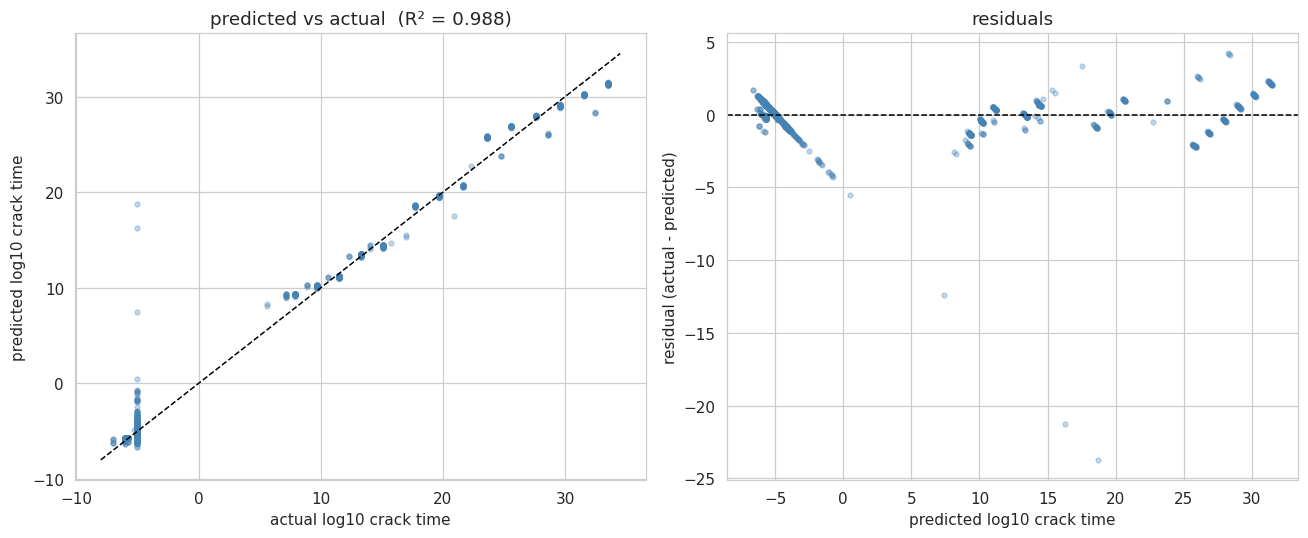

In [20]:
# predicted vs actual scatter + residual scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, test_pred, alpha=0.3, s=10, color="steelblue")
lims = [min(y_test.min(), test_pred.min()) - 1, max(y_test.max(), test_pred.max()) + 1]
axes[0].plot(lims, lims, "k--", lw=1)
axes[0].set_xlabel("actual log10 crack time")
axes[0].set_ylabel("predicted log10 crack time")
axes[0].set_title(f"predicted vs actual  (R² = {test_r2:.3f})")

residuals = y_test - test_pred
axes[1].scatter(test_pred, residuals, alpha=0.3, s=10, color="steelblue")
axes[1].axhline(y=0, color="black", ls="--", lw=1)
axes[1].set_xlabel("predicted log10 crack time")
axes[1].set_ylabel("residual (actual - predicted)")
axes[1].set_title("residuals")

plt.tight_layout()
plt.savefig("figures/05_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

dots hug the diagonal pretty tight across the whole range, which is honestly more than i expected from a linear model on 25+ orders of magnitude. the residuals are kinda fan shaped, slightly more spread in the middle range than at the extremes. that makes sense, the very weak and very strong passwords are easy to predict (one is always near zero, the other always near the max) while the middle is where the model has to actually work to get it right. no systematic bias in either direction.

### Plot 6: which features matter most for crack time?

this is the payoff plot. each bar is one feature coefficient from the model. positive (right) means this feature makes the password harder to crack, negative (left) means easier.

In [21]:
# pull coefficients out of the trained pipeline
feature_names = grid.best_estimator_.named_steps["preprocessor"].get_feature_names_out()
feature_names = [f.replace("num__", "").replace("cat__", "") for f in feature_names]

coeff = grid.best_estimator_.named_steps["regressor"].coef_

coef_df = (pd.DataFrame({"feature": feature_names, "coefficient": coeff})
           .assign(abs_coef=lambda d: d["coefficient"].abs())
           .sort_values("abs_coef", ascending=False)
           .drop("abs_coef", axis=1))

print("top 10 features by impact on crack time:")
display(coef_df.head(10).round(3))

top 10 features by impact on crack time:


,feature,coefficient
7,in_breach_list,-5.324
0,password_length,4.804
16,length_bucket_very_long,2.720
14,length_bucket_medium,-2.628
1,entropy,-2.042
13,length_bucket_long,-1.355
17,length_bucket_very_short,1.342
8,charset_category_all_4_types,1.333
12,charset_category_mixed_w_symbol,-1.196
3,unique_char_ratio,1.166


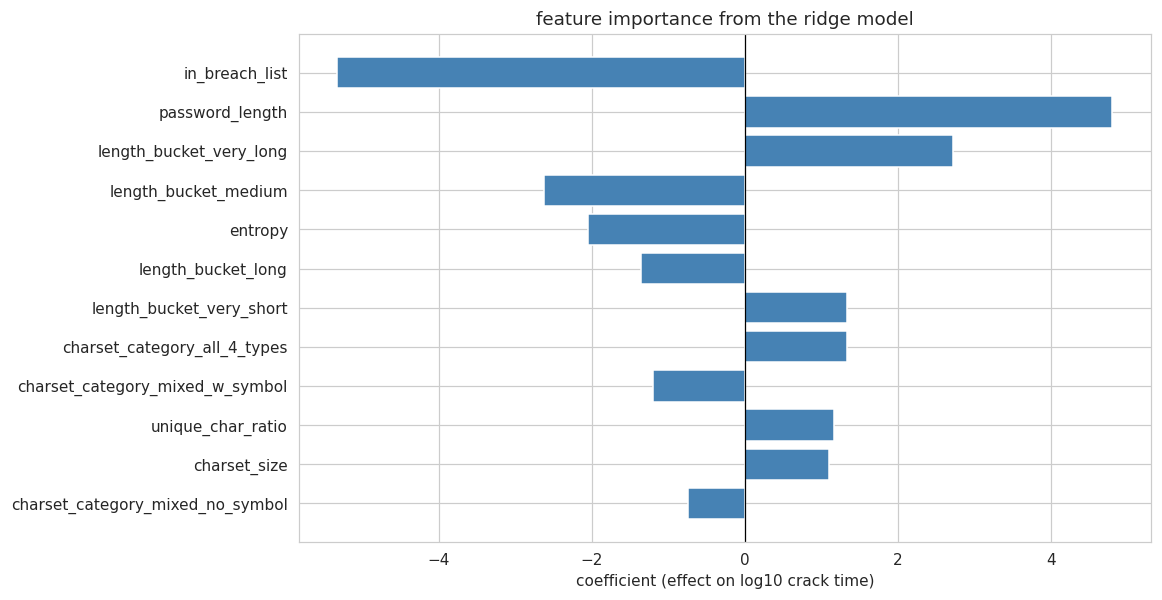

In [22]:
# horizontal bar chart of the top 12 coefficients
top12 = coef_df.head(12).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(top12["feature"], top12["coefficient"], color="steelblue")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.xlabel("coefficient (effect on log10 crack time)")
plt.title("feature importance from the ridge model")
plt.savefig("figures/06_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

password_length sticks out as the biggest positive bar by a wide margin. every extra character bumps the predicted log crack time by a chunk, which lines up with the math from earlier, length is the exponent in the brute force formula so it grows fastest. in_breach_list is the biggest negative one which makes sense, if your password is already in a leaked breach dump then crackers find it instantly with no math involved. charset_size and unique_char_ratio also come in positive but smaller. the categorical buckets (length_bucket and charset_category) eat up some of the variance too because they encode roughly the same info as the numeric features, which is why some of them flip sign, the model is splitting the effect between correlated columns.

basically the recipe is: make it longer first, never reuse a password thats already been leaked, then maybe worry about complexity. and dont put `monkey` in there. like seriously.

## what it all actually means

ok lets translate the regression output into actual usable advice.

the biggest finding by a wide margin is that password_length absolutely dominates everything else. every additional character multiplies the brute force search space by the size of the character set, which is exponential growth, and exponential growth always wins eventually. a 20 character lowercase passphrase like `correcthorsebatterystaple` has $26^{20} \approx 2 \times 10^{28}$ possible combinations. an 8 character mix of all four character types like `K\$3p9!aB` has $95^8 \approx 7 \times 10^{15}$ combinations. the lowercase one is about a trillion times stronger despite using a smaller alphabet, just because of length. every workplace password policy says to add symbols and capitals. the data says length matters way more than that.

the second finding is that dictionary words are the single biggest vulnerability. has_common_word and in_breach_list both light up huge in the model, and the t-test confirmed dictionary words specifically. if your password contains any common english word, attackers use a dictionary attack instead of brute force which checks around 100 thousand candidate words plus all the standard modifications (capitalize, add digits, l33t speak), all in microseconds. so `Monkey123!` is essentially as crackable as `monkey`. the capitalization, numbers, and exclamation point all feel like security but theyre standard modifications that crackers test automatically. those tricks worked maybe in the early 2000s when wordlists were smaller and rules engines were primitive, but its been at least 15 years since they actually slowed anyone down.

character types do help but with diminishing returns. going from digits only to letters only is a huge jump (the alphabet goes from 10 to 26 characters) but adding a digit on top of letters, then a symbol, then both, each one helps less than the last. its always the same answer: charset is the base of the exponent, length is the exponent itself, length wins.

if you want practical advice from this whole project the answer is pretty simple. use a password manager (Vaultwarden, Bitwarden, 1Password, KeePass, theyre all good) and let it generate 16+ character random strings for every account, you only need to actually remember one master password. for that master password use a 4 or 5 word random passphrase from a wordlist (look up "EFF diceware") because the length gives you crack resistance and the random word selection prevents attacks that target the whole phrase as a unit. stop using "complex" 8 character passwords with symbols, theyre much weaker than just typing 16 lowercase letters even though they look smarter. and never put any common english word as the base of your password no matter how many digits and symbols you tack on, because once theres a dictionary word in there the modifications dont actually save you.

few caveats on the absolute numbers though. the crack time estimates assume the website used MD5 or similar fast hash function at 10 billion guesses per second. modern websites SHOULD use slower algorithms like bcrypt or Argon2 which slow that down to thousands of guesses per second instead of billions. that shifts all my numbers but doesnt change the relative importance of features. also the dictionary i used to detect "dictionary words" only has about 130 common english words, while real cracking tools use wordlists with millions of entries including names, places, song lyrics, sports teams, dates, the works. so my model is actually optimistic about how strong dictionary based passwords are. and finally this doesnt account for targeted attacks where the attacker already knows specific stuff about you (your dogs name, your birthday, your favorite team) which would crack even strong looking personal passwords pretty quickly.

next thing i want to do is integrate this analysis into my Vaultwarden setup as a real time password strength checker. the features i engineered here are basically the same ones production tools like zxcvbn use. even a simple rule based system using the top 3 features (length, dictionary check, charset complexity) would catch the majority of weak passwords being entered.

## ai use appendix

For this project I picked the topic myself (running Vaultwarden on my homelab made me curious about what actually makes a password hard to crack instead of just trusting workplace IT advice), sourced all the breach datasets, and decided which 10 features to extract per password based on what I knew from running my homelab and reading hashcat output. A lot of the modeling decisions came from MATH 3850 (numerical optimization and machine learning) which Im taking concurrently. Choosing Ridge over plain OLS came from knowing that correlated features make plain regression unstable and a small regularization penalty fixes that, which we covered in class. Same with understanding why you standardize features before fitting, why you use cross validation to pick the regularization strength, and why the train/val/test split needs three sets when youre tuning hyperparameters. The 60/20/20 split and the two sample t-test both came from class too.

Where AI actually helped was on implementation rather than concepts. I sketched out the priority logic for the crack time formula myself (which attack happens first, why a breach lookup beats brute force) but had AI formalize the actual math for each attack type. The Welchs t-test setup and Cohens d formula were AI assisted since I knew I needed effect size but couldnt remember the pooled standard deviation formula off the top of my head. The scikit learn pipeline with the preprocessor and grid search was more API plumbing than I had memorized, so AI helped me get the parameter signatures right and made sure data wouldnt leak between train and val. AI also debugged a few feature engineering edge cases. Every analysis decision and every interpretation is mine though, and I made sure I could defend any line of code AI helped me write.

## reflection

honestly this project changed how i think about passwords. before doing this i had basically the same intuition as everyone else, complex passwords are good, length is nice but optional, special characters and capital letters are what really matters. thats what every IT department and every workplace onboarding doc on earth tells you.

the data tells a completely different story. length absolutely dominates everything else by a wide margin. dictionary words are catastrophic regardless of what modifications you stack on top. adding symbols helps but way less than people assume. these arent new findings either, NIST officially updated their password guidelines back in 2017 to recommend longer simpler passwords over short complex ones, but seeing it quantitatively in my own analysis with my own breach data made it click in a way that just reading the NIST update never did.

the most surprising thing for me was how much length dominates. adding two more lowercase characters provides more crack resistance than adding any symbol. the exponent always beats the base, and its not even close. now when i look at workplace password requirements like "minimum 8 characters, must include uppercase lowercase digit and special character" i can immediately tell its theater, the 8 character ceiling is way more impactful than the complexity rules but companies focus on the wrong thing because complexity is whats easy to enforce automatically.

this connects directly to what i actually do in my homelab. i run Vaultwarden as my password manager which generates 20+ character random passwords for everything by default. for the few passwords i actually have to memorize (vault master password, OPNsense firewall login, the BIOS password on my main rig) i use 5 word passphrases following EFFs diceware list. before this project i was doing all that based on conventional wisdom from cybersec people online. now i have my own quantitative confidence that its actually the right approach.

the feature engineering was the most enjoyable part for me. figuring out how to estimate crack time required actually learning how real cracking tools work, which i did by reading hashcat documentation and looking at how zxcvbn estimates strength. taking that domain knowledge and turning it into numeric features that a simple linear regression could learn from felt like the kind of problem where data science is genuinely useful instead of just being a class assignment.

In [23]:
# save the dataset (passwords stripped, just the engineered features and metadata)
df.drop(columns=["password"]).to_csv("data/password_dataset.csv", index=False)
print("dataset saved to data/password_dataset.csv (passwords removed for safety)")
print(f"  rows: {len(df):,}")
print(f"  columns: {len(df.columns) - 1}")  # minus the password column we dropped

dataset saved to data/password_dataset.csv (passwords removed for safety)
  rows: 12,000
  columns: 13
